# c50py Tour

This notebook demonstrates the features of `c50py`, a Python implementation of the C5.0 decision tree algorithm.

In [ ]:
!pip install -q "c50py>=0.5.0"

## 1. Classification (Titanic)
We'll start by training a classifier on the Titanic dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from c50py import C5Classifier

# Load data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df = df.dropna(subset=["Embarked"])

# Select features
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features].values
y = df["Survived"].values

# Initialize and fit
clf = C5Classifier(
    min_samples_split=20,
    categorical_features=["Pclass", "Sex", "Embarked"]
)
clf.fit(X, y, feature_names=features)

# Print the tree
clf.print_tree()

if Sex in {male}:
  if Pclass in {1}:
    if Fare <= 26.1438:
      Predict 0 | dist={np.int64(0): 10.0, np.int64(1): 0.0}
    else:
      if Age <= 53.0000:
        if Fare <= 27.1354:
          Predict 1 | dist={np.int64(0): 1.7789473684210526, np.int64(1): 10.778947368421052}
        else:
          Predict 0 | dist={np.int64(0): 44.56842105263157, np.int64(1): 30.115789473684213}
      else:
        Predict 0 | dist={np.int64(0): 20.652631578947364, np.int64(1): 4.105263157894737}
  else:
    if Age <= 9.5000:
      if Pclass in {3}:
        Predict 0 | dist={np.int64(0): 20.24431818181819, np.int64(1): 8.767045454545455}
      else:
        Predict 1 | dist={np.int64(0): 0.5965909090909091, np.int64(1): 9.170454545454545}
    else:
      Predict 0 | dist={np.int64(0): 370.1590909090909, np.int64(1): 46.0625}
else:
  if Pclass in {3}:
    if Fare <= 23.3500:
      Predict 1 | dist={np.int64(0): 48.0, np.int64(1): 69.0}
    else:
      Predict 0 | dist={np.int64(0): 24.0, np.int64(1

### Drawing the tree
`plot_tree` works exactly like `sklearn.tree.plot_tree`: same arguments, same boxes, same colours.

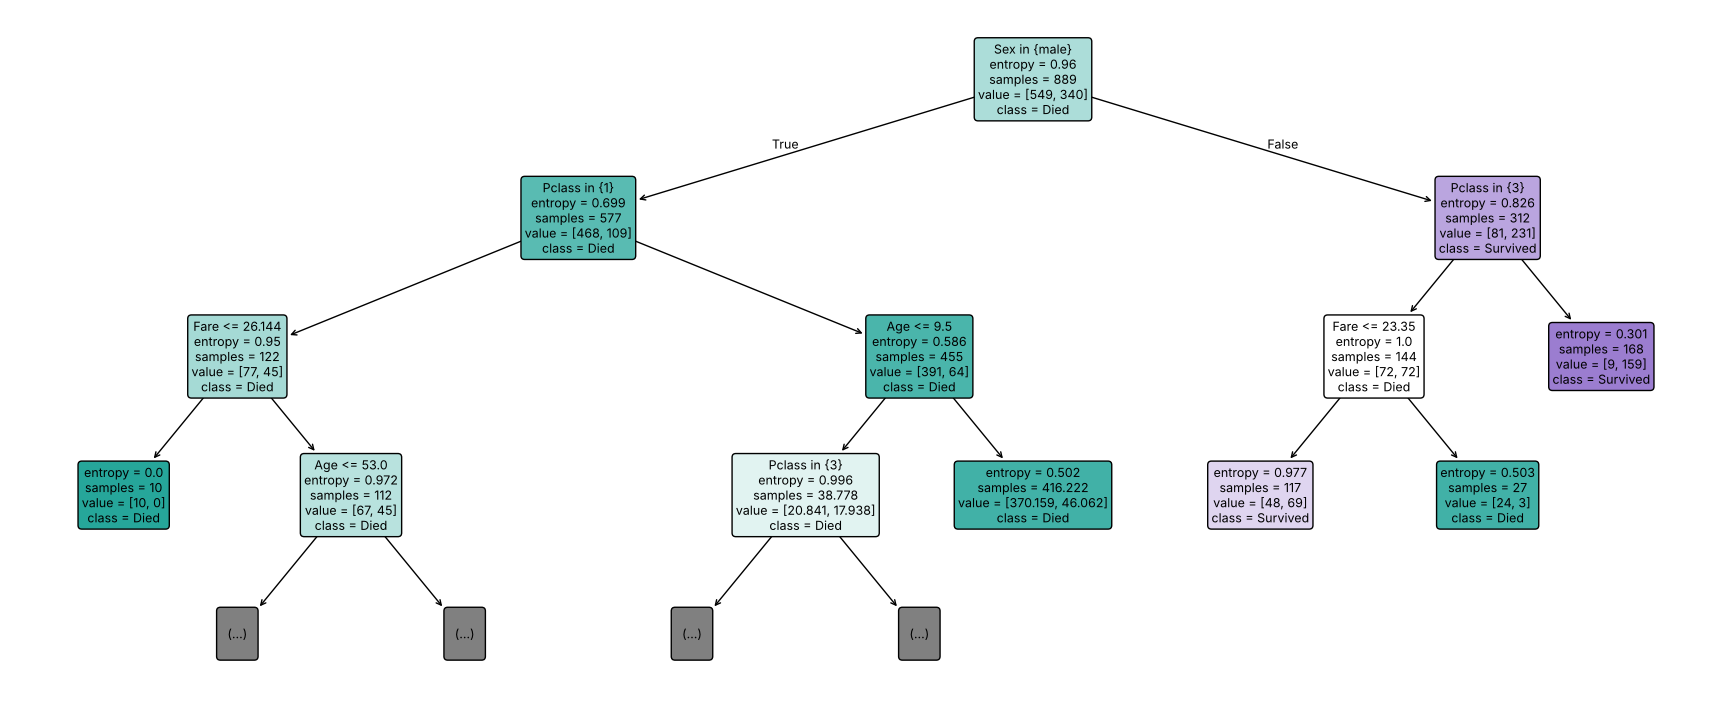

In [3]:
fig, ax = plt.subplots(figsize=(22, 9))
clf.plot_tree(class_names=["Died", "Survived"], filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
plt.show()

## 2. Regression (Diabetes)
Now let's try a regression problem.

R^2 Score: 0.8413


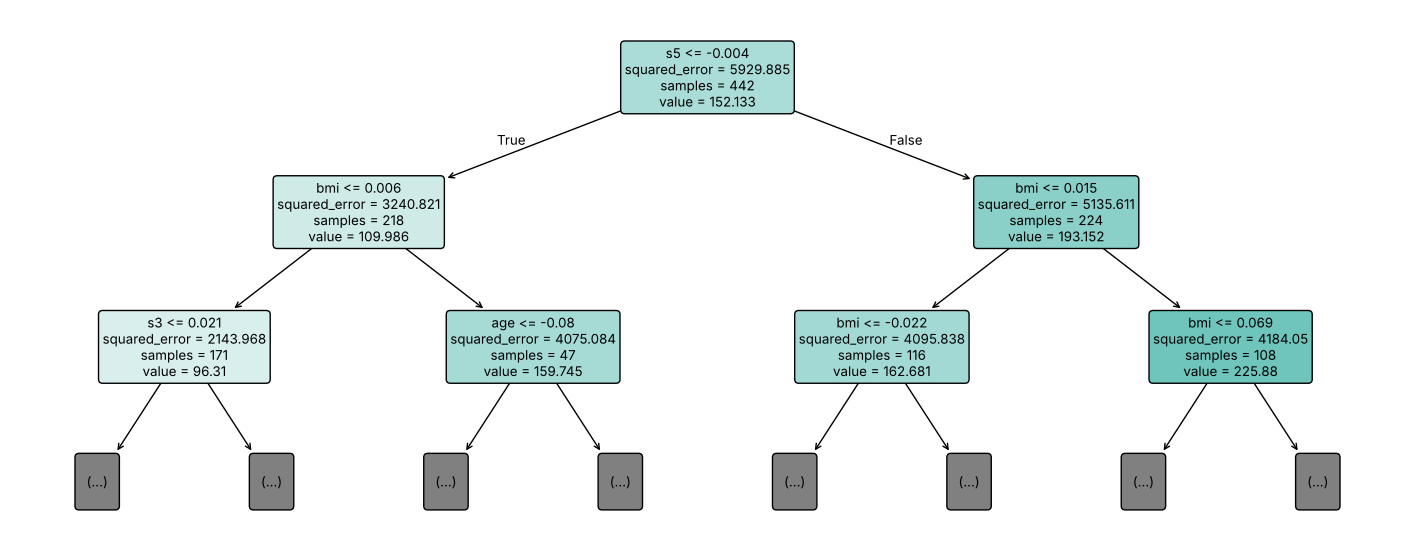

In [4]:
from sklearn.datasets import load_diabetes
from c50py import C5Regressor

data = load_diabetes()
X_reg, y_reg = data.data, data.target
features_reg = data.feature_names

reg = C5Regressor(min_samples_split=10, pruning=True)
reg.fit(X_reg, y_reg, feature_names=features_reg)

print(f"R^2 Score: {reg.score(X_reg, y_reg):.4f}")

fig, ax = plt.subplots(figsize=(18, 7))
reg.plot_tree(filled=True, rounded=True, max_depth=2, ax=ax)
plt.show()

## 3. Advanced Features
### Sample Weights
We can assign weights to samples. Let's weight the positive class heavily.

In [5]:
weights = np.ones(len(y))
weights[y == 1] = 5.0
clf_weighted = C5Classifier(min_samples_split=20, categorical_features=["Pclass", "Sex", "Embarked"])
clf_weighted.fit(X, y, sample_weight=weights, feature_names=features)
clf_weighted.print_tree()

if Sex in {female}:
  if Pclass in {3}:
    if Fare <= 23.3500:
      Predict 1 | dist={np.int64(0): 48.0, np.int64(1): 345.0}
    else:
      if Parch <= 0.5000:
        Predict 1 | dist={np.int64(0): 0.0, np.int64(1): 5.0}
      else:
        Predict 0 | dist={np.int64(0): 24.0, np.int64(1): 10.0}
  else:
    Predict 1 | dist={np.int64(0): 9.0, np.int64(1): 795.0}
else:
  if Pclass in {1}:
    if Age <= 53.0000:
      if Parch <= 1.5000:
        if Parch <= 0.5000:
          if Age <= 47.5000:
            if Age <= 45.2500:
              Predict 1 | dist={np.int64(0): 34.08497998191915, np.int64(1): 120.75778122174867}
            else:
              Predict 0 | dist={np.int64(0): 7.5472469757630565, np.int64(1): 0.855073399629773}
          else:
            Predict 1 | dist={np.int64(0): 5.283481854578328, np.int64(1): 45.130440397778635}
        else:
          if Age <= 37.5000:
            Predict 1 | dist={np.int64(0): 3.0, np.int64(1): 15.0}
          else:
            Predict

### Missing Values
Let's predict on an instance with a missing value.

In [6]:
# Create a test instance with missing Age (index 2)
# Pclass=3, Sex=male, Age=NaN, SibSp=0, Parch=0, Fare=7.25, Embarked=S
x_miss = [[3, "male", np.nan, 0, 0, 7.25, "S"]]
pred = clf.predict(x_miss)
print(f"Prediction for missing age: {pred[0]}")

Prediction for missing age: 0


### Boosting
Train an ensemble of trees. Each tree of the ensemble can be drawn with `tree_index`.

Boosted Accuracy: 0.8954   trees: 10


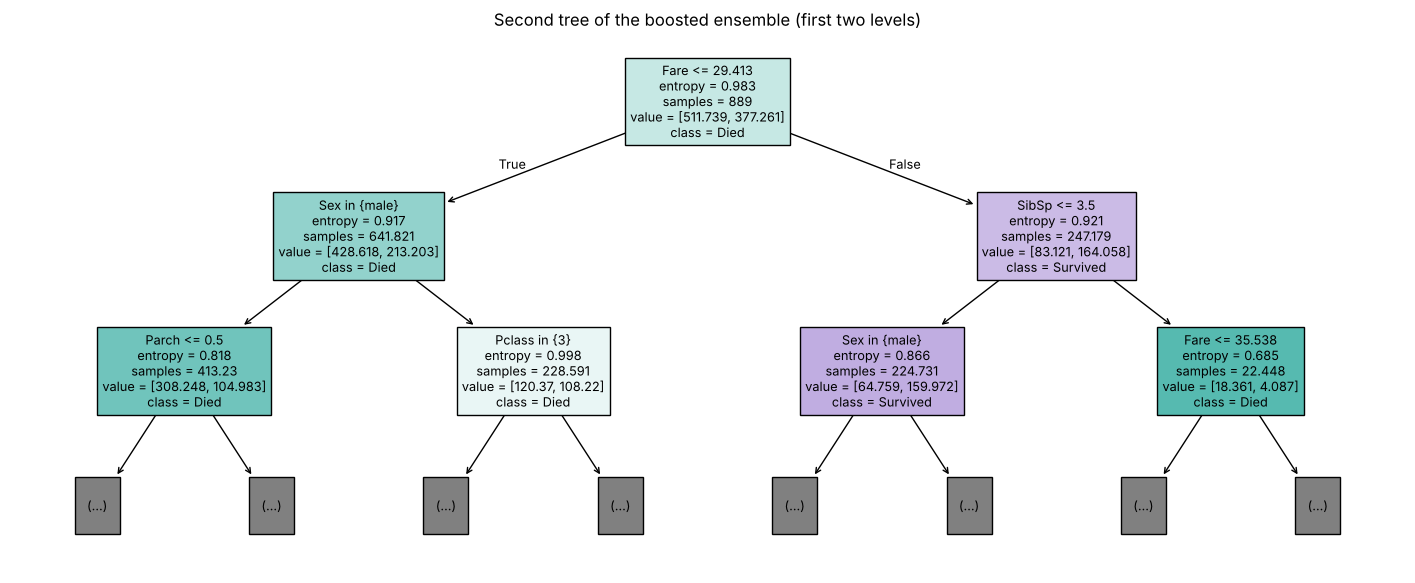

In [7]:
boosted_clf = C5Classifier(trials=10, categorical_features=["Pclass", "Sex", "Embarked"])
boosted_clf.fit(X, y, feature_names=features)
print(f"Boosted Accuracy: {boosted_clf.score(X, y):.4f}   trees: {len(boosted_clf.ensemble_)}")

fig, ax = plt.subplots(figsize=(18, 7))
boosted_clf.plot_tree(tree_index=1, class_names=["Died", "Survived"], filled=True, max_depth=2, ax=ax)
ax.set_title("Second tree of the boosted ensemble (first two levels)")
plt.show()